In [18]:
import pandas as pd
file_path = r"C:\Code\ott-churn-prediction\_data\01_raw\Membership.csv"
df = pd.read_csv(file_path)

### age
 >10 미만은 제거하고 그 후 이상치 제거 

In [19]:
import pandas as pd

# Z-score 기준값 설정
threshold = 3

# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# age가 10 이상인 데이터만 사용
df_age_10 = df[df["age"] >= 10].copy()

# 평균, 표준편차 계산
mean_value = df_age_10["age"].mean()
std_value = df_age_10["age"].std()

# 실제 값 기준 하한값, 상한값 계산
lower_bound = mean_value - (threshold * std_value)
upper_bound = mean_value + (threshold * std_value)

# 이상치 제거 데이터프레임 생성
df_age_cleaned = df_age_10[
    (df_age_10["age"] >= lower_bound) & (df_age_10["age"] <= upper_bound)
].copy()

# 결과 확인
print("원래 데이터 수:", len(df))
print("10 미만 제거 후 데이터 수:", len(df_age_10))
print("이상치 제거 후 데이터 수:", len(df_age_cleaned))
print("제거된 이상치 수:", len(df_age_10) - len(df_age_cleaned))
print("실제 하한값(age):", round(lower_bound, 2))
print("실제 상한값(age):", round(upper_bound, 2))


원래 데이터 수: 18183
10 미만 제거 후 데이터 수: 18013
이상치 제거 후 데이터 수: 17962
제거된 이상치 수: 51
실제 하한값(age): -3.85
실제 상한값(age): 71.72


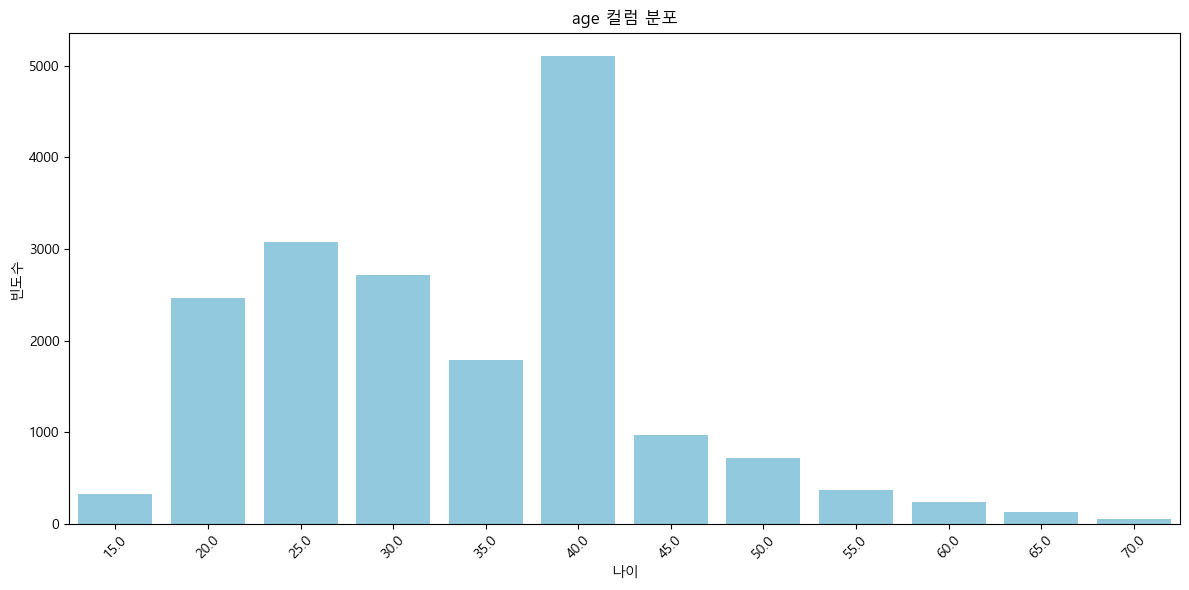

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# age 컬럼 수치형 변환
df_age_cleaned["age"] = pd.to_numeric(df_age_cleaned["age"], errors="coerce")

# 결측치 제거 후 나이별 빈도수 계산
age_count = df_age_cleaned["age"].dropna().value_counts().sort_index()

# 한글 출력 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 막대그래프 생성
sns.barplot(x=age_count.index, y=age_count.values, color="skyblue")

# 그래프 제목 및 축 이름 설정
plt.title("age 컬럼 분포")
plt.xlabel("나이")
plt.ylabel("빈도수")

# x축 눈금 회전
plt.xticks(rotation=45)

# 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()


### concurrent_streams
 >10세 미만, 이상치 제거 age + 달러 이상치 처리 amount + 이상치 처리 conc_streams

In [21]:
import pandas as pd

# concurrent_streams 컬럼 수치형 변환
df_age_cleaned["concurrent_streams"] = pd.to_numeric(
    df_age_cleaned["concurrent_streams"],
    errors="coerce"
)

# concurrent_streams가 1, 2, 4인 행만 선택
df_age_amount_streams_cleaned = df_age_cleaned[
    df_age_cleaned["concurrent_streams"].isin([1, 2, 4])
].copy()

# 결과 확인
print("변환 전 데이터 수:", len(df_age_cleaned))
print("필터링 후 데이터 수:", len(df_age_amount_streams_cleaned))
print("제외된 행 수:", len(df_age_cleaned) - len(df_age_amount_streams_cleaned))


변환 전 데이터 수: 17962
필터링 후 데이터 수: 17890
제외된 행 수: 72


## Multi

### is_user_verified + gender
 > is_user_verified가 'Y'인데 gender가 'N'인 행을 최빈값 (F)로 대체, 47건

In [22]:
# is_user_verified == 'Y'이면서 gender == 'N'인 행의 gender를 최빈값 'F'로 대체
df_final_cleaned = df_age_amount_streams_cleaned.copy()
mask = (df_final_cleaned["is_user_verified"] == "Y") & (df_final_cleaned["gender"] == "N")
df_final_cleaned.loc[mask, "gender"] = "F"

# 결과 확인
print("전체 데이터 수:", len(df_final_cleaned))
print("대체된 행 수:", mask.sum())

전체 데이터 수: 17890
대체된 행 수: 47


In [23]:
# import pandas as pd

# # 조건에 해당하는 행 제거
# df_final_cleaned = df_age_amount_streams_cleaned[
#     ~(
#         (df_age_amount_streams_cleaned["is_user_verified"] == "Y") &
#         (df_age_amount_streams_cleaned["gender"] == "N")
#     )
# ].copy()

# # 결과 확인
# print("제거 전 데이터 수:", len(df_age_amount_streams_cleaned))
# print("제거 후 데이터 수:", len(df_final_cleaned))
# print("제거된 행 수:", len(df_age_amount_streams_cleaned) - len(df_final_cleaned))

### reg_date + end_date + repurchase
 > reg_date와 end_date가 같은데 repurchase가 "O"인 행 삭제

In [24]:
import pandas as pd

# 날짜형 변환
df_final_cleaned["reg_date"] = pd.to_datetime(df_final_cleaned["reg_date"], errors="coerce")
df_final_cleaned["end_date"] = pd.to_datetime(df_final_cleaned["end_date"], errors="coerce")

# reg_date와 end_date가 같은 행 개수 확인
same_date_count = (df_final_cleaned["reg_date"] == df_final_cleaned["end_date"]).sum()

print("reg_date와 end_date가 같은 행 수:", same_date_count)


reg_date와 end_date가 같은 행 수: 357


In [25]:
import pandas as pd

# 날짜형 변환
df_final_cleaned["reg_date"] = pd.to_datetime(df_final_cleaned["reg_date"], errors="coerce")
df_final_cleaned["end_date"] = pd.to_datetime(df_final_cleaned["end_date"], errors="coerce")

# 삭제 조건 생성
delete_mask = (
    (df_final_cleaned["reg_date"] == df_final_cleaned["end_date"]) &
    (df_final_cleaned["repurchase"] == "O")
)

# 제거 후 데이터 생성
df_reg_end_cleaned = df_final_cleaned[~delete_mask].copy()

# 결과 확인
print("제거 전 데이터 수:", len(df_final_cleaned))
print("제거 후 데이터 수:", len(df_reg_end_cleaned))
print("제거된 행 수:", delete_mask.sum())


제거 전 데이터 수: 17890
제거 후 데이터 수: 17876
제거된 행 수: 14


### amount + is_user_verified
> amount == 100인데 is_user_verified가 "N" 이거나 NaN(결측)인 경우를 모두 "Y"로 변경

In [26]:
import pandas as pd

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# amount 숫자형 변환
temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# is_user_verified 문자열 정리
temp["is_user_verified"] = temp["is_user_verified"].fillna("").astype(str).str.strip()

# 변경 조건: amount == 100이고 is_user_verified가 "N" 또는 결측("")인 경우
replace_mask = (
    (temp["amount"] == 100) &
    (temp["is_user_verified"].isin(["N", ""]))
)

# 조건에 해당하는 행의 is_user_verified를 "Y"로 변경
temp.loc[replace_mask, "is_user_verified"] = "Y"
df_reg_end_cleaned = temp.copy()

# 결과 확인
print("전체 데이터 수:", len(df_reg_end_cleaned))
print("변경된 행 수:", replace_mask.sum())


전체 데이터 수: 17876
변경된 행 수: 352


In [27]:
df_reg_end_cleaned[df_reg_end_cleaned["amount"] == 100]["is_user_verified"].value_counts()


is_user_verified
Y    9061
Name: count, dtype: int64

In [28]:
# import pandas as pd

# # 분석용 복사본 생성
# temp = df_reg_end_cleaned.copy()

# # amount 숫자형 변환
# temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# # is_user_verified 문자열 정리
# temp["is_user_verified"] = temp["is_user_verified"].fillna("").astype(str).str.strip()

# # 삭제 조건 생성
# delete_mask = (
#     (temp["amount"] == 100) &
#     (temp["is_user_verified"] != "Y")
# )

# # 조건에 해당하는 행 삭제
# df_reg_end_cleaned = temp[~delete_mask].copy()

# # 결과 확인
# print("삭제 전 데이터 수:", len(temp))
# print("삭제 후 데이터 수:", len(df_reg_end_cleaned))
# print("삭제된 행 수:", delete_mask.sum())


# Payment Device  

> payment_device에는 다음의 컬럼이 존재함.

> android ios lgchplus lgtv mobile ott ott_cjhello pc smarttv sstv  
 
lgchplus, lgtv, smarttv, sstv는 smarttv로,  
ott, ott_cjhello는 ott로 그룹화.  
ios, android, pc, mobile는 그대로 두기  

In [29]:
device_map = {
    "lgchplus": "smarttv",
    "lgtv":     "smarttv",
    "smarttv":  "smarttv",
    "sstv":     "smarttv",
    "ott":      "ott",
    "ott_cjhello": "ott",
}

df_reg_end_cleaned["payment_device"] = (
    df_reg_end_cleaned["payment_device"]
    .str.strip()
    .str.lower()
    .replace(device_map)
)

# 확인
df_reg_end_cleaned["payment_device"].value_counts()


payment_device
android    8381
pc         3438
ios        2996
mobile     2746
smarttv     253
ott          62
Name: count, dtype: int64

# 원핫 인코딩

In [30]:
o_cols = ["promotion_yn", "is_churn_prevented", "repurchase"]

for col in o_cols:
    df_reg_end_cleaned[col] = (
        df_reg_end_cleaned[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("O")
        .astype(int)
    )

df_reg_end_cleaned["is_user_verified"] = (
    df_reg_end_cleaned["is_user_verified"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("Y")
    .astype(int)
)

for col in o_cols + ["is_user_verified"]:
    print(f"[{col}]")
    print(df_reg_end_cleaned[col].value_counts())
    print()


[promotion_yn]
promotion_yn
1    9061
0    8815
Name: count, dtype: int64

[is_churn_prevented]
is_churn_prevented
0    14660
1     3216
Name: count, dtype: int64

[repurchase]
repurchase
1    11831
0     6045
Name: count, dtype: int64

[is_user_verified]
is_user_verified
1    13755
0     4121
Name: count, dtype: int64



# 컬럼 이름 변경

In [31]:
rename_cols = {
    "user_no": "USER_KEY",
    "product_cd": "product_code",
    "amount": "price",
    "concurrent_streams": "max_screen",
    "promotion_yn": "is_promotion",
    "repurchase": "is_repurchase"
}

df_reg_end_cleaned = df_reg_end_cleaned.rename(columns=rename_cols)

df_reg_end_cleaned.head()


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.00,134,4.0,1,0,0,pc,1,F,20.0,2021-03-14,20,2021-04-14
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.00,190,1.0,1,1,0,pc,1,F,25.0,2021-03-09,14,2021-04-09
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.00,132,1.0,1,0,0,android,1,F,55.0,2021-03-09,22,2021-04-09
3,445fb8813626d3d49b94b5be58cd76d80ed31fa94f8372...,pk_1508,9.99,140,1.0,0,0,1,ios,0,N,40.0,2021-03-09,10,2021-04-10
4,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.00,180,2.0,1,0,1,android,1,F,20.0,2021-03-09,2,2021-04-09


In [32]:
import os

# 저장 경로 설정
save_dir = r"C:\Code\ott-churn-prediction\_data\02_interim\260430 전처리 수정"
file_path = os.path.join(save_dir, "membership_v1.csv")

# 폴더 없으면 생성
os.makedirs(save_dir, exist_ok=True)

# CSV 저장
df_reg_end_cleaned.to_csv(file_path, index=False, encoding="utf-8-sig")

# 저장 경로 확인
print("저장 완료:", file_path)


저장 완료: C:\Code\ott-churn-prediction\_data\02_interim\260430 전처리 수정\membership_v1.csv
